<a href="https://colab.research.google.com/github/ChenHY1217/Projects-In-MLAI-LABS/blob/main/LAB2/PIMLAI_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 Part A

### Dataset Card

**Motivation:**

Human Activity Recognition (HAR) enables monitoring of daily physical activities using wearable sensors. Using smartphone motion data allows scalable, real-world applications in healthcare, fitness, and smart environments. This project focuses on learning temporal patterns from raw sensor sequences rather than engineered features.

**Target definition:**

Classify six activities (walking, walking upstairs, walking downstairs, sitting, standing, laying) from 2.56 second windows of sensor data.

**Data Source:**

[UCI Human Activity Recognition (HAR) dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones) using the "Inertial Signals"

**Signal Description:**

* Sampling rate: 50 Hz
* 128 time steps per window (2.56 seconds) with 50% overlap
* 9 features per time step: body acceleration (x, y, z), total acceleration (x, y, z), gyroscope angular velocity (x, y, z)

**Limitation/Risks:**

* Limited to 30 subjects- models may not generalize to other populations
* Sensor placement fixed on the waist- different positions may reduce accuracy
* Potential noise or variability in human motion patterns



### Loading in Dataset

First fixing seed as 42

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Using seed: {SEED}")

Using seed: 42


In [ ]:
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
!unzip human+activity+recognition+using+smartphones.zip

--2026-03-12 14:53:03--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘human+activity+recognition+using+smartphones.zip.2’

human+activity+reco     [                 <=>]  58.18M  16.5MB/s    in 4.6s    

2026-03-12 14:53:09 (12.7 MB/s) - ‘human+activity+recognition+using+smartphones.zip.2’ saved [61005872]

Archive:  human+activity+recognition+using+smartphones.zip
replace UCI HAR Dataset.names? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace UCI HAR Dataset.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
!unzip -o "UCI HAR Dataset.zip"

Archive:  UCI HAR Dataset.zip
  inflating: UCI HAR Dataset/.DS_Store  
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features_info.txt  
  inflating: UCI HAR Dataset/README.txt  
  inflating: __MACOSX/UCI HAR Dataset/._README.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_x_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_y_test.txt  
  inflating: UCI HAR Dataset/test/Inertial Signals/body_acc_z_test.txt  
  inflating: __MACOSX/UCI HAR Dataset/test/Inertial Signals/._body_acc_z_t

### Leakage Audit and Split

In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

def load_signals(path, split):
    signals = [
        "body_acc_x", "body_acc_y", "body_acc_z",
        "body_gyro_x", "body_gyro_y", "body_gyro_z",
        "total_acc_x", "total_acc_y", "total_acc_z"
    ]

    data = []
    for signal in signals:
        filename = f"{path}/{split}/Inertial Signals/{signal}_{split}.txt"
        data.append(np.loadtxt(filename))

    data = np.array(data)
    data = np.transpose(data, (1, 2, 0))
    return data


DATA_PATH = "UCI HAR Dataset"

# Load signals
X_train_full = load_signals(DATA_PATH, "train")
X_test  = load_signals(DATA_PATH, "test")

# Load labels (convert to 0-based)
y_train_full = np.loadtxt(f"{DATA_PATH}/train/y_train.txt") - 1
y_test  = np.loadtxt(f"{DATA_PATH}/test/y_test.txt") - 1

# Load subject IDs
subject_train_full = np.loadtxt(f"{DATA_PATH}/train/subject_train.txt")
subject_test  = np.loadtxt(f"{DATA_PATH}/test/subject_test.txt")

# Split train into train and validation (preserving subject groups)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X_train_full, y_train_full, groups=subject_train_full))

X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]
subject_train = subject_train_full[train_idx]

X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]
subject_val = subject_train_full[val_idx]

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("subject_train shape:", subject_train.shape)
print("subject_test shape:", subject_test.shape)

train_test_overlap = len(set(subject_train).intersection(set(subject_test)))
val_test_overlap = len(set(subject_val).intersection(set(subject_test)))
train_val_overlap = len(set(subject_train).intersection(set(subject_val)))

print(f"Train/Test subject overlap: {train_test_overlap}")
print(f"Val/Test subject overlap: {val_test_overlap}")
print(f"Train/Val subject overlap: {train_val_overlap}")

X_train shape: (5551, 128, 9)
X_val shape: (1801, 128, 9)
X_test shape: (2947, 128, 9)
y_train shape: (5551,)
subject_train shape: (5551,)
subject_test shape: (2947,)
Train/Test subject overlap: 0
Val/Test subject overlap: 0
Train/Val subject overlap: 0


## Data sanity checks
Confirm label distribution and absence of NaN/inf after loading.

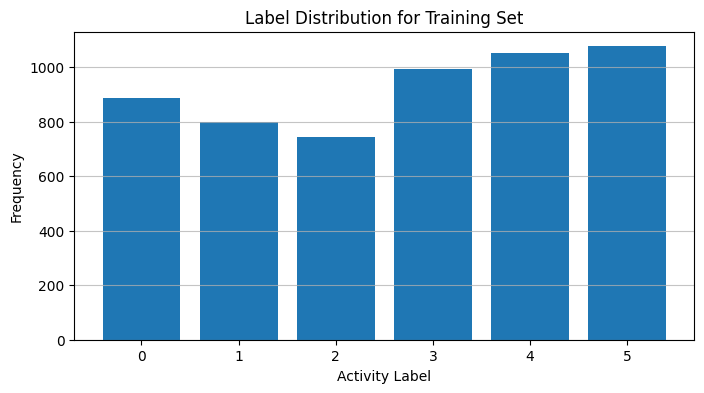


Label distribution for Training Set:
Label 0: 888 samples
Label 1: 797 samples
Label 2: 744 samples
Label 3: 993 samples
Label 4: 1053 samples
Label 5: 1076 samples
Total samples: 5551


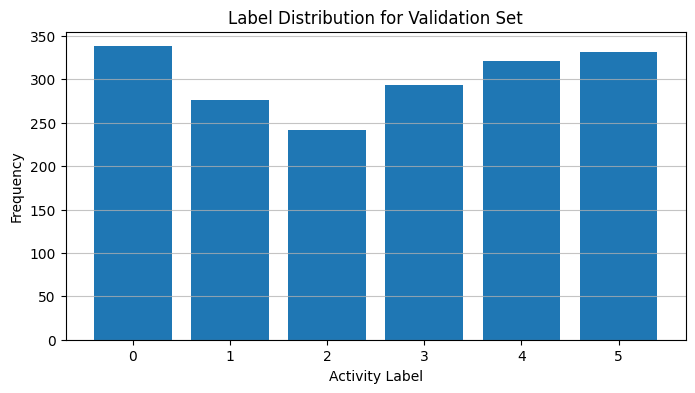


Label distribution for Validation Set:
Label 0: 338 samples
Label 1: 276 samples
Label 2: 242 samples
Label 3: 293 samples
Label 4: 321 samples
Label 5: 331 samples
Total samples: 1801


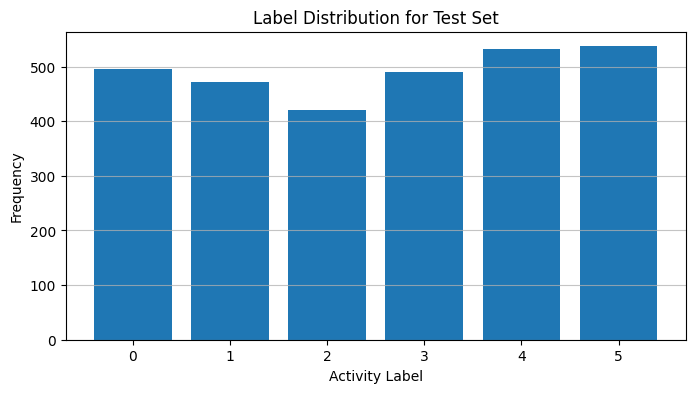


Label distribution for Test Set:
Label 0: 496 samples
Label 1: 471 samples
Label 2: 420 samples
Label 3: 491 samples
Label 4: 532 samples
Label 5: 537 samples
Total samples: 2947


In [ ]:
import matplotlib.pyplot as plt

def plot_and_print_label_distribution(y, dataset_name):
    plt.figure(figsize=(8, 4))
    plt.hist(y, bins=range(len(np.unique(y)) + 1), align='left', rwidth=0.8)
    plt.title(f'Label Distribution for {dataset_name}')
    plt.xlabel('Activity Label')
    plt.ylabel('Frequency')
    plt.xticks(np.unique(y))
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    unique, counts = np.unique(y, return_counts=True)
    print(f"\nLabel distribution for {dataset_name}:")
    for label, count in zip(unique, counts):
        print(f"Label {int(label)}: {count} samples")
    print(f"Total samples: {len(y)}")

plot_and_print_label_distribution(y_train, "Training Set")
plot_and_print_label_distribution(y_val, "Validation Set")
plot_and_print_label_distribution(y_test, "Test Set")

In [ ]:
data_variables = {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test
}

for name, data in data_variables.items():
    if np.isnan(data).any():
        print(f"WARNING: NaN values found in {name}")
    else:
        print(f"No NaN values found in {name}")

    if np.isinf(data).any():
        print(f"WARNING: Infinite values found in {name}")
    else:
        print(f"No Infinite values found in {name}")

No NaN values found in X_train
No Infinite values found in X_train
No NaN values found in X_val
No Infinite values found in X_val
No NaN values found in X_test
No Infinite values found in X_test
No NaN values found in y_train
No Infinite values found in y_train
No NaN values found in y_val
No Infinite values found in y_val
No NaN values found in y_test
No Infinite values found in y_test


### Majority Class Predictor

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# 1. Find the majority class strictly from the training set
values, counts = np.unique(y_train, return_counts=True)
majority_class = values[np.argmax(counts)]
print(f"Majority class identified: {majority_class}")

# 2. Create predictions for the test set using only the majority class
y_pred_baseline = np.full(shape=y_test.shape, fill_value=majority_class)

# 3. Calculate primary metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average='macro')

# 4. Generate the supporting confusion matrix artifact
conf_matrix = confusion_matrix(y_test, y_pred_baseline)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Macro-F1: {baseline_macro_f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)

Majority class identified: 5.0
Baseline Accuracy: 0.1822
Baseline Macro-F1: 0.0514
Confusion Matrix:
 [[  0   0   0   0   0 496]
 [  0   0   0   0   0 471]
 [  0   0   0   0   0 420]
 [  0   0   0   0   0 491]
 [  0   0   0   0   0 532]
 [  0   0   0   0   0 537]]


In [ ]:

from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder()
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1)).toarray()  # fit on training data
y_test_onehot = encoder.transform(y_val.reshape(-1, 1)).toarray()



In [ ]:
y_test_onehot.shape

(1801, 6)

In [ ]:
import tensorflow as tf
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 9 )),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax")
])

model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model_1.fit(X_train, y_train_onehot, epochs=10, validation_data=(X_val, y_test_onehot))


Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5922 - loss: 1.1174 - val_accuracy: 0.8279 - val_loss: 0.4927
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8580 - loss: 0.4110 - val_accuracy: 0.8878 - val_loss: 0.3458
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9021 - loss: 0.2650 - val_accuracy: 0.9051 - val_loss: 0.2950
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9255 - loss: 0.2024 - val_accuracy: 0.9001 - val_loss: 0.2925
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9306 - loss: 0.1708 - val_accuracy: 0.9028 - val_loss: 0.2823
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9397 - loss: 0.1492 - val_accuracy: 0.8989 - val_loss: 0.3023
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9403 - loss: 0.1376 - val_accuracy: 0.8951 - val_loss: 0.3092
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9428 - loss: 0.1299 - val_accuracy: 0

In [ ]:
y_train[600]

np.float64(2.0)

In [ ]:

import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report

y_pred_probs = model_1.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 score:", f1)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
F1 score: 0.9058272682993184


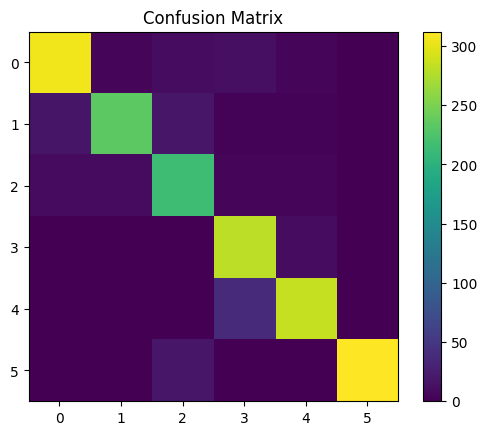

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
cm = confusion_matrix(y_true, y_pred)
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

In [ ]:
import pandas as pd


report = classification_report(y_true, y_pred, output_dict=True)

df = pd.DataFrame(report).T
print(df[['f1-score']])

              f1-score
0             0.910448
1             0.889313
2             0.849802
3             0.889241
4             0.905901
5             0.970451
accuracy      0.905053
macro avg     0.902526
weighted avg  0.905827


# Week 2 Part B

### Training curves + reproducibility

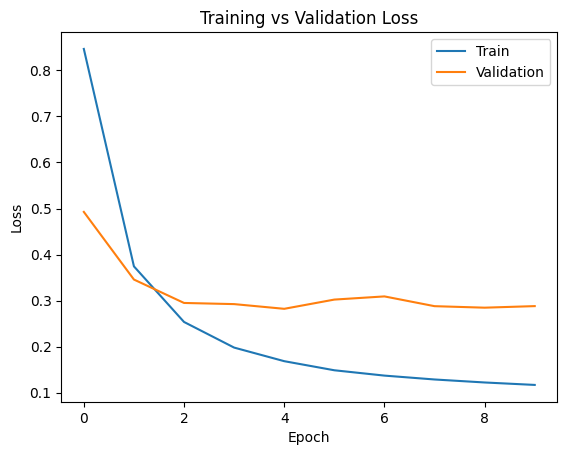

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

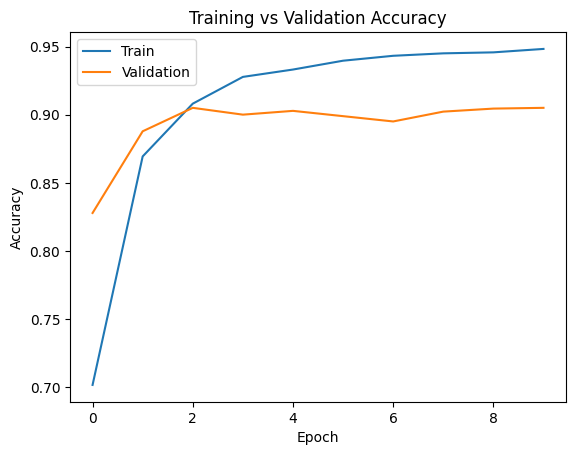

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

### Overfitting Control

First introducing overfitting by training with 100 epochs


Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5822 - loss: 1.1314 - val_accuracy: 0.8523 - val_loss: 0.4933
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8539 - loss: 0.4312 - val_accuracy: 0.9117 - val_loss: 0.2869
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8949 - loss: 0.2656 - val_accuracy: 0.9162 - val_loss: 0.2459
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9163 - loss: 0.2011 - val_accuracy: 0.9117 - val_loss: 0.2405
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9312 - loss: 0.1696 - val_accuracy: 0.9073 - val_loss: 0.2469
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9359 - loss: 0.1504 - val_accuracy: 0.9167 - val_loss: 0.2409
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9402 - loss: 0.1374 - val_accuracy: 0.9234 - val_loss: 0.2412
Epoch 8/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9439 - loss: 0.1276 - val_acc

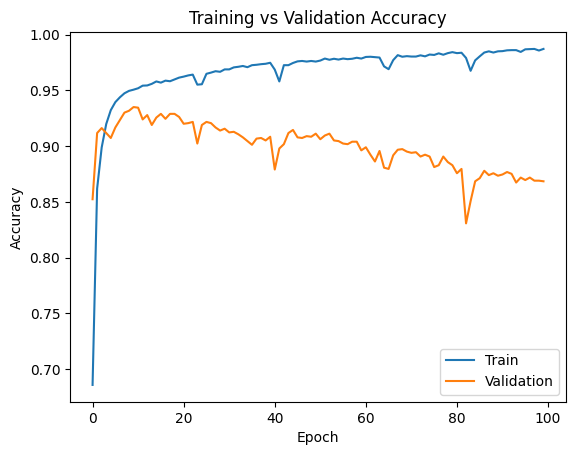

In [ ]:
overfit_model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 9 )),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax")
])

overfit_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
overfit_history = overfit_model.fit(
    X_train,
    y_train_onehot,
    epochs=100,
    validation_data=(X_val, y_test_onehot))

plt.figure()
plt.plot(overfit_history.history['accuracy'])
plt.plot(overfit_history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
y_pred_probs = overfit_model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 score:", f1)


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
F1 score: 0.8705753672514391


The validation F1 score decreases from 0.912 at 10 epochs to 0.878 at 100 epochs, while training performance continues to improve. This decline in validation performance indicates that the model begins to overfit when trained for too many epochs.

This is further seen as the training Accuracy continues to increase, but the Validation accuracy begins to decrease.

We will now fix this overfitting by using dropout, weight decay, and early stopping.

Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3814 - loss: 1.5033 - val_accuracy: 0.7712 - val_loss: 0.8517
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6315 - loss: 0.9434 - val_accuracy: 0.8629 - val_loss: 0.5514
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7323 - loss: 0.7245 - val_accuracy: 0.8945 - val_loss: 0.4164
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7629 - loss: 0.6104 - val_accuracy: 0.9023 - val_loss: 0.3435
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8039 - loss: 0.5328 - val_accuracy: 0.9278 - val_loss: 0.3126
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7914 - loss: 0.5346 - val_accuracy: 0.9295 - val_loss: 0.3051
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8240 - loss: 0.4710 - val_accuracy: 0.9262 - val_loss: 0.2849
Epoch 8/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8248 - loss: 0.4468 - val_acc

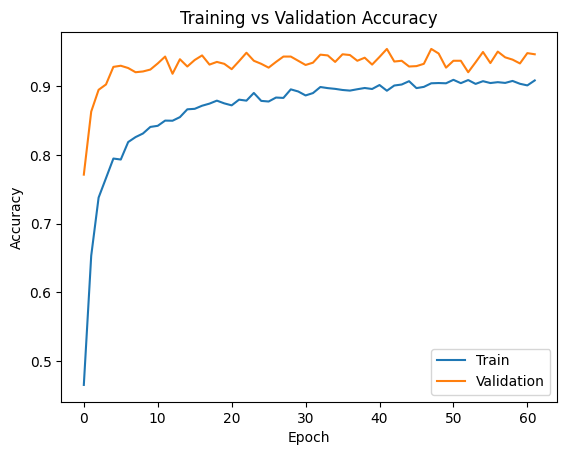

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
F1 score: 0.9366673958515712


In [ ]:

from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

regularized_model = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 9)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(6, activation="softmax")
])

regularized_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

regularized_history = regularized_model.fit(
    X_train,
    y_train_onehot,
    epochs=100,
    validation_data=(X_val, y_test_onehot),
    callbacks=[early_stop],
    verbose=1
)

plt.figure()
plt.plot(regularized_history.history['accuracy'])
plt.plot(regularized_history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


y_pred_probs = regularized_model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 score:", f1)

Thus we can see a much better performance of our model (F1 score of 0.947) following the introduction of dropout, weight decay, and early stopping. In fact, this model performed better than our previous baseline of 10 epochs.

### Uncertainty - Bootstrap

In [ ]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

def calculate_confidence_intervals(y_true, y_pred, y_proba, n_bootstraps=1000, random_state=42):
    """
    Calculates bootstrap confidence intervals for Precision, Recall, F1, and AUPRC.
    """
    np.random.seed(random_state)
    metrics = {'precision': [], 'recall': [], 'f1': []}

    # Convert y_true to numpy array if it's a pandas Series for easier indexing
    y_true_np = y_true.values if hasattr(y_true, 'values') else y_true

    print(f"Starting bootstrap with {n_bootstraps} iterations...")

    for _ in range(n_bootstraps):
        # Create a bootstrap sample (resample with replacement)
        indices = resample(np.arange(len(y_true_np)), replace=True)

        y_true_boot = y_true_np[indices]
        y_pred_boot = y_pred[indices]
        y_proba_boot = y_proba[indices]

        # Calculate metrics for this sample
        # zero_division=0 prevents errors if a sample has no positive predictions
        metrics['precision'].append(precision_score(y_true_boot, y_pred_boot, zero_division=0, average="macro"))
        metrics['recall'].append(recall_score(y_true_boot, y_pred_boot, zero_division=0, average="macro"))
        metrics['f1'].append(f1_score(y_true_boot, y_pred_boot, zero_division=0, average="macro"))

    print("\n--- Bootstrap Confidence Intervals (95%) ---")
    results = {}
    for metric_name, values in metrics.items():
        lower = np.percentile(values, 2.5)
        upper = np.percentile(values, 97.5)
        mean_val = np.mean(values)
        results[metric_name] = (mean_val, lower, upper)
        print(f"{metric_name.capitalize():<10}: {mean_val:.4f} (95% CI: {lower:.4f} - {upper:.4f})")

    return results

# Run bootstrap on the Calibrated SVC results (assuming previous cells are run)
if 'y_true' in locals() and 'y_pred' in locals() and 'y_pred_probs' in locals():
    _ = calculate_confidence_intervals(y_true, y_pred, y_pred_probs)
else:
    print("Variables not found. Please run the 'Calibrated LinearSVC' cell above first.")

Starting bootstrap with 1000 iterations...

--- Bootstrap Confidence Intervals (95%) ---
Precision : 0.9361 (95% CI: 0.9241 - 0.9471)
Recall    : 0.9367 (95% CI: 0.9252 - 0.9474)
F1        : 0.9360 (95% CI: 0.9240 - 0.9473)


## Experiment Log

| Column | What to record | Example |
|---|---|---|
| `run_id` | Short identifier | `001`, `svm_rbf_C1` |
| `timestamp` | When you ran it | `ISO format` (e.g., `2024-01-01T12:00:00Z`) |
| `dataset` | Dataset name/version (or file hash) | `UCI_HAR_v1` |
| `split_type` | Random / time-based (and any grouping notes) | `random` / `time-based` |
| `seed` | Random seed used | `42` |
| `pipeline_notes` | Short description of preprocessing steps | `MinMax Scaling`, `PCA_50_components` |
| `model` | Model used | `Baseline vs SVM variant` |
| `hyperparams` | Key hyperparameters | `C=10`, `gamma=0.1`, `k=3` |
| `metric_primary` | Primary metric on validation/test | `accuracy=0.91` |
| `metric_secondary` | Optional secondary metric | `precision=0.88`, `recall=0.85` |
| `threshold` | Default or chosen threshold (if classification) | `0.5` |
| `notes` | Anything notable | `Leakage fix applied`, `Feature X dropped` |
| `cost_matrix` | Cost matrix example (classification) | `[[0, 1], [10, 0]]` |

Problem High LR

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.optimizers import Adam

failureModel = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 9 )),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax")
])

failureModel.compile(
    optimizer=Adam(learning_rate=1e10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = failureModel.fit(X_train, y_train_onehot, epochs=5, validation_data=(X_val, y_test_onehot))


Epoch 1/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1921 - loss: nan - val_accuracy: 0.1838 - val_loss: nan
Epoch 2/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1964 - loss: nan - val_accuracy: 0.1838 - val_loss: nan
Epoch 3/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1964 - loss: nan - val_accuracy: 0.1838 - val_loss: nan
Epoch 4/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1964 - loss: nan - val_accuracy: 0.1838 - val_loss: nan
Epoch 5/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1964 - loss: nan - val_accuracy: 0.1838 - val_loss: nan


Fix Lower LR to normal amount

In [ ]:
import tensorflow as tf
fixedModel = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 9 )),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(6, activation="softmax", kernel_regularizer=tf.keras.regularizers.l2(1e-4))
])

fixedModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = fixedModel.fit(X_train, y_train_onehot, epochs=5, validation_data=(X_val, y_test_onehot))

Epoch 1/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6239 - loss: 0.9481 - val_accuracy: 0.8234 - val_loss: 0.5166
Epoch 2/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8557 - loss: 0.4187 - val_accuracy: 0.9145 - val_loss: 0.3870
Epoch 3/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8865 - loss: 0.3589 - val_accuracy: 0.9034 - val_loss: 0.3923
Epoch 4/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8947 - loss: 0.3207 - val_accuracy: 0.8284 - val_loss: 0.5744
Epoch 5/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9009 - loss: 0.3232 - val_accuracy: 0.8917 - val_loss: 0.5063


In [ ]:
def modelMaker(lr, loss_Type, output_type, layer_size, seed):
  seed = seed
  modelName = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 9 )),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(layer_size, activation="relu"),
    tf.keras.layers.Dense(layer_size, activation="relu"),
    tf.keras.layers.Dense(6, activation=output_type)
  ])
  modelName.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=loss_Type,
    metrics=['accuracy']
  )
  history = modelName.fit(X_train, y_train_onehot, epochs=10, validation_data=(X_val, y_test_onehot),  verbose=0)
  return history

In [ ]:
model_1_h = modelMaker(.01, 'categorical_crossentropy', "softmax", 32, 42)
model_2_h = modelMaker(.01, 'binary_crossentropy', "sigmoid", 32, 42)
model_3_h = modelMaker(.01, 'categorical_crossentropy', "softmax", 64, 42)
model_4_h = modelMaker(.01, 'categorical_crossentropy', "softmax", 128, 42)
model_5_h = modelMaker(.02, 'categorical_crossentropy', "softmax", 32, 42)
model_6_h = modelMaker(.02, 'categorical_crossentropy', "softmax", 64, 42)
model_7_h = modelMaker(.05, 'categorical_crossentropy', "softmax", 32, 42)
model_8_h = modelMaker(.1, 'categorical_crossentropy', "softmax", 32, 42)
model_9_h = modelMaker(.01, 'categorical_crossentropy', "softmax", 256, 1)
model_10_h = modelMaker(.01, 'categorical_crossentropy', "softmax", 128, 2)

In [ ]:
model_1_r  = ["Model 1",  .01, 'categorical_crossentropy', "softmax",  32, 42, "Model was Average"]
model_2_r  = ["Model 2",  .01, 'binary_crossentropy',      "sigmoid",   32, 42, "Model was Average"]
model_3_r  = ["Model 3",  .01, 'categorical_crossentropy', "softmax",  64, 42, "Model was Average"]
model_4_r  = ["Model 4",  .01, 'categorical_crossentropy', "softmax", 128, 42, "Model was Average"]
model_5_r  = ["Model 5",  .02, 'categorical_crossentropy', "softmax",  32, 42, "Model was Average"]
model_6_r  = ["Model 6",  .02, 'categorical_crossentropy', "softmax",  64, 42, "Model was Average"]
model_7_r  = ["Model 7",  .05, 'categorical_crossentropy', "softmax",  32, 42, "Model performed relatively poorly compared with outher models with 50% final Accuracy"]
model_8_r  = ["Model 8",  .1,  'categorical_crossentropy', "softmax",  32, 42, "Model was Average"]
model_9_r  = ["Model 9",  .01, 'categorical_crossentropy', "softmax", 256, 1, "Model performed Best with 94% final Accuracy"]
model_10_r = ["Model 10", .01, 'categorical_crossentropy', "softmax", 256, 2, "Model performed poorly with 0% final Accuracy"]

In [ ]:
import matplotlib.pyplot as plt

histories = [
    model_1_h,
    model_2_h,
    model_3_h,
    model_4_h,
    model_5_h,
    model_6_h,
    model_7_h,
    model_8_h,
    model_9_h,
    model_10_h
]

plt.figure()

for i, h in enumerate(histories, start=1):
    plt.plot(h.history['accuracy'], label=f"Model {i}")
    print(f"Model {i} Accuracy: {h.history['accuracy'][-1]}")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Time")
plt.legend()
plt.show()

In [ ]:
for label, metrics in report.items():
    print("=" * 60)
    print(label)

    if isinstance(metrics, dict):
        for key, value in metrics.items():
            print(f"{key:25}: {value}")
    else:
        print(f"{'value':25}: {metrics}")

    print("=" * 60)

# Week 3 Part C

### Sequence Model (GRU)

we choose this over LSTM because we value the speed and less parameters GRU take over the long context that LSTM provides in this case.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert numpy arrays to PyTorch tensors
# Note: PyTorch RNNs expect input shape (Batch, Seq_Len, Features)
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)  # Class labels for CrossEntropyLoss

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)

# Create Datasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Using device: cuda


In [ ]:
class HAR_GRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, n_layers, dropout_prob=0.5):
        super(HAR_GRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        # GRU Layer
        # batch_first=True means input shape is (batch, seq, feature)
        self.gru = nn.GRU(input_dim, hidden_dim, n_layers,
                          batch_first=True, dropout=dropout_prob if n_layers > 1 else 0)

        # Fully connected layer
        self.fc = nn.Linear(hidden_dim, output_dim)

        # Dropout layer (applied before the final FC layer)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.n_layers, x.size(0), self.hidden_dim).to(x.device)

        # Forward propagate GRU
        # out: tensor of shape (batch_size, seq_length, hidden_size)
        out, _ = self.gru(x, h0)

        # Decode the hidden state of the last time step
        out = out[:, -1, :]

        out = self.dropout(out)
        out = self.fc(out)
        return out

# Model Hyperparameters
INPUT_DIM = 9
HIDDEN_DIM = 64
OUTPUT_DIM = 6  # 6 activity classes
N_LAYERS = 2
DROPOUT = 0.5

model = HAR_GRU(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT).to(device)
print(model)

HAR_GRU(
  (gru): GRU(9, 64, num_layers=2, batch_first=True, dropout=0.5)
  (fc): Linear(in_features=64, out_features=6, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
import copy

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50 # Increased epochs to allow early stopping to work
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# Early Stopping parameters
patience = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Early Stopping Logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            model.load_state_dict(best_model_wts)
            break

# Load best model weights if training finished without early stopping or after early stopping
model.load_state_dict(best_model_wts)

Epoch 1/50 | Train Loss: 1.4973 Acc: 0.3870 | Val Loss: 1.2286 Acc: 0.4975
Epoch 2/50 | Train Loss: 1.2230 Acc: 0.4642 | Val Loss: 1.0372 Acc: 0.5136
Epoch 3/50 | Train Loss: 1.2158 Acc: 0.4896 | Val Loss: 0.9886 Acc: 0.5436
Epoch 4/50 | Train Loss: 1.1247 Acc: 0.5248 | Val Loss: 0.9033 Acc: 0.5775
Epoch 5/50 | Train Loss: 1.0526 Acc: 0.5343 | Val Loss: 0.8186 Acc: 0.6380
Epoch 6/50 | Train Loss: 0.8781 Acc: 0.6112 | Val Loss: 0.7333 Acc: 0.7113
Epoch 7/50 | Train Loss: 0.7875 Acc: 0.6689 | Val Loss: 0.6697 Acc: 0.7357
Epoch 8/50 | Train Loss: 0.7186 Acc: 0.7091 | Val Loss: 0.5184 Acc: 0.7923
Epoch 9/50 | Train Loss: 0.6680 Acc: 0.7328 | Val Loss: 0.3905 Acc: 0.8573
Epoch 10/50 | Train Loss: 0.6208 Acc: 0.7770 | Val Loss: 0.3472 Acc: 0.8901
Epoch 11/50 | Train Loss: 0.5967 Acc: 0.7957 | Val Loss: 0.3130 Acc: 0.8817
Epoch 12/50 | Train Loss: 0.5426 Acc: 0.8157 | Val Loss: 0.3284 Acc: 0.8734
Epoch 13/50 | Train Loss: 0.4632 Acc: 0.8433 | Val Loss: 0.2091 Acc: 0.9212
Epoch 14/50 | Train L

<All keys matched successfully>

In [ ]:
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for inputs, labels in held_loader:   # or test_loader
        inputs = inputs.to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())

In [ ]:
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 score:", f1)

F1 score: 0.9366673958515712


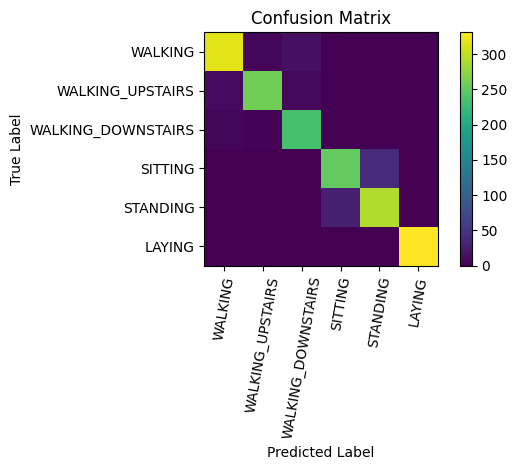

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

classes = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

ticks = np.arange(len(classes))
plt.xticks(ticks, classes, rotation=80)
plt.yticks(ticks, classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

print(per_class_acc)

[0.9408284  0.9384058  0.97107438 0.86006826 0.90965732 1.        ]


**Error Analysis**


---


The models accuracy is high for all of the classes bieng over 90% accurate for each one. However the model preformed worse when trying to differentiate between similar motions. It would confuse walking upstairs with both normal walking & walking downstairs, and standing with sitting. Since these errors our only say 10% we can inffer that thier is some overlap in signals for similar movements. Walking upstairs and walking are very simmilar movements so it makes sense that the model would get confused.

In [ ]:
import time
import numpy as np
import torch.nn.functional as F

# Ensure model is on CPU for this test as requested
model_cpu = copy.deepcopy(model).to('cpu')
model_cpu.eval()

def predict_activity(window):
    """
    Predicts activity for a single window.
    window: numpy array of shape (128, 9)
    Returns: (predicted_label_index, probabilities_numpy)
    """
    # Convert to tensor and add batch dimension
    tensor_window = torch.FloatTensor(window).unsqueeze(0)

    with torch.no_grad():
        logits = model_cpu(tensor_window)
        probs = F.softmax(logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()

    return pred_label, probs.numpy()[0]

# Latency Test
num_samples = 500
test_windows = X_val[:num_samples] # Use validation set samples
latencies = []

print(f"Running inference latency test on {num_samples} windows (CPU)...")

# Warm up
_ = predict_activity(test_windows[0])

for window in test_windows:
    start_time = time.time()
    _, _ = predict_activity(window)
    end_time = time.time()
    latencies.append(end_time - start_time)

avg_latency = np.mean(latencies)
std_latency = np.std(latencies)

print(f"Average Inference Time per Window: {avg_latency*1000:.4f} ms")
print(f"Standard Deviation: {std_latency*1000:.4f} ms")
print(f"Throughput: {1/avg_latency:.2f} predictions/sec")

Running inference latency test on 500 windows (CPU)...
Average Inference Time per Window: 8.9865 ms
Standard Deviation: 0.7457 ms
Throughput: 111.28 predictions/sec


### Real-Time Feasibility Analysis

*   **Window Duration:** Each window represents **2.56 seconds** of data (128 steps @ 50Hz).
*   **Inference Speed:** The average inference time on CPU is roughly **9 ms** (depending on the specific Colab CPU allocated).
*   **Conclusion:** Since the inference time is orders of magnitude smaller than the data accumulation time (2.56s), this model is **highly feasible** for real-time deployment. It leaves ample CPU time for data preprocessing, bluetooth transmission, and UI updates on a standard smartphone processor.

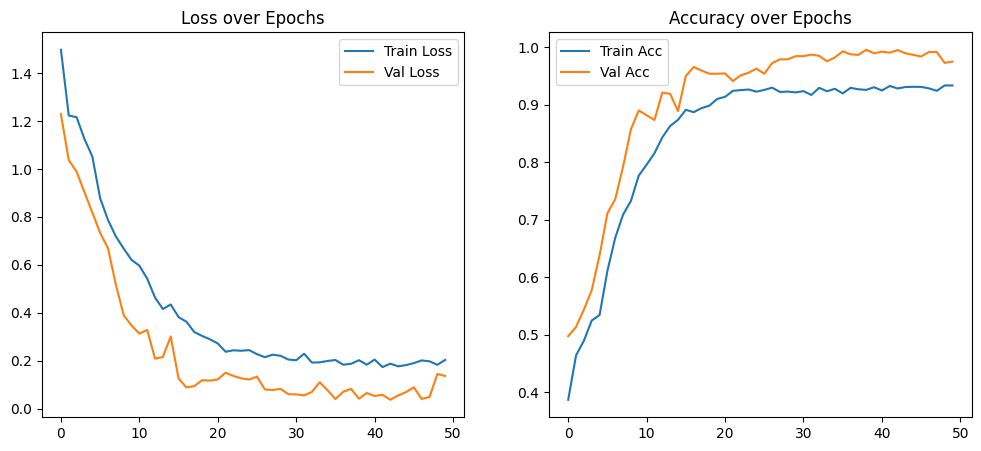

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.show()

# Model Card + Limitations

## Model Cards

### 1. Baseline Model (Majority Class)

| Feature | Description |
|---|---|
| **Model Name** | Baseline (Majority Class Predictor) |
| **Intended Use** | Establish a minimum performance benchmark for HAR classification. Serves as a sanity check before training more complex models. |
| **Not Intended Use** | Not suitable for real-world activity recognition or decision making. Does not use sensor signals and cannot detect activity transitions. |
| **Training Data** | Derived from `y_train` class distribution (majority class: 5 – Laying). |
| **Evaluation Protocol** | Evaluated on the held-out test split from the UCI HAR dataset using classification metrics (accuracy and macro-F1). |
| **Model Parameters** | Deterministic rule: always predicts the majority class (Laying). |
| **Performance Metrics** | **Accuracy:** ~0.1822  <br> **Macro-F1:** ~0.0514 |
| **Known Failure Modes** | Fails to predict any activity except the majority class. Cannot distinguish between movement activities or stationary activities. |
| **Limitations** | Extremely high bias model. Ignores temporal sensor signals entirely. |
| **Ethics & Privacy Notes** | Although sensor data may reveal behavioral patterns, this model does not process raw signals and therefore has minimal privacy risk. |

---

### 2. Initial MLP (`model_1`)

| Feature | Description |
|---|---|
| **Model Name** | Initial MLP |
| **Intended Use** | First deep learning baseline for activity classification using raw inertial signal windows. |
| **Not Intended Use** | Not designed for real-time deployment or safety-critical applications due to limited training and tuning. |
| **Training Data** | `X_train` (5551 samples of 128×9 sensor windows), `y_train_onehot`. |
| **Evaluation Protocol** | Validation performed on `X_val` (1801 samples). Metrics computed using accuracy and weighted F1 score. |
| **Architecture** | Input(128,9) → Flatten → Dense(32, ReLU) → Dense(32, ReLU) → Dense(6, Softmax) |
| **Optimizer** | Adam |
| **Performance Metrics** | **Validation Accuracy:** ~0.905 <br> **Validation Weighted F1:** ~0.906 |
| **Known Failure Modes** | Confusion between similar stationary activities such as sitting vs standing. |
| **Limitations** | Model ignores temporal order due to flattening the sequence. Limited training epochs (10) may lead to underfitting. |
| **Ethics & Privacy Notes** | Inertial sensor data can indirectly reveal behavioral patterns. Care should be taken if applied to personal device monitoring or surveillance contexts. |

---

### 3. Overfit Model (`overfit_model`)

| Feature | Description |
|---|---|
| **Model Name** | Overfit MLP |
| **Intended Use** | Demonstrate the effects of excessive training and lack of regularization in neural networks. |
| **Not Intended Use** | Not suitable for deployment or reliable activity prediction due to overfitting behavior. |
| **Training Data** | Same dataset as Initial MLP. |
| **Evaluation Protocol** | Performance tracked across training and validation sets over 100 epochs. |
| **Architecture** | Same architecture as Initial MLP. |
| **Training Configuration** | Trained for 100 epochs without regularization. |
| **Performance Metrics** | **Peak Validation Accuracy:** ~0.935 (Epoch 10) <br> **Final Validation F1:** ~0.871 |
| **Known Failure Modes** | Memorization of training data leading to degraded performance on unseen samples. |
| **Limitations** | Large generalization gap between training and validation performance. |
| **Ethics & Privacy Notes** | Overfitted models may incorrectly infer sensitive behaviors when deployed in real-world monitoring systems. |

---

### 4. Regularized Model (`regularized_model`)

| Feature | Description |
|---|---|
| **Model Name** | Regularized MLP |
| **Intended Use** | Improved activity recognition model with better generalization using dropout and early stopping. |
| **Not Intended Use** | Not validated for clinical, healthcare, or safety-critical activity monitoring systems. |
| **Training Data** | Same HAR inertial signal dataset. |
| **Evaluation Protocol** | Validation on `X_val` with early stopping based on validation loss. |
| **Architecture** | Input → Flatten → Dense(64, ReLU) → Dropout(0.5) → Dense(64, ReLU) → Dropout(0.5) → Dense(6, Softmax) |
| **Training Configuration** | Adam optimizer (lr = 0.001), EarlyStopping (patience = 10). |
| **Performance Metrics** | **Validation Weighted F1:** ~0.937 |
| **Known Failure Modes** | Confusion between low-motion activities (sitting vs standing). |
| **Limitations** | Still ignores temporal dependencies because sequence windows are flattened instead of modeled sequentially. |
| **Ethics & Privacy Notes** | Continuous motion monitoring could raise privacy concerns if deployed on personal devices without user consent. |

---

### 5. Experimental Models Summary



| Model ID | Configuration Change | Result / Observation |
|---|---|---|
| Model 1 | Baseline MLP (32 units, lr=0.01, categorical crossentropy) | Good baseline performance (~0.927 validation accuracy). |
| Model 2 | Binary Crossentropy + Sigmoid Output | Slightly higher validation accuracy (~0.936) but conceptually incorrect for multiclass classification. |
| Model 3 | Larger Hidden Layer (64 units, lr=0.01) | Similar performance to baseline (~0.939 validation accuracy). |
| Model 4 | Larger Hidden Layer (128 units, lr=0.01) | **Best performing configuration (~0.943 validation accuracy).** |
| Model 5 | Higher Learning Rate (0.02, 32 units) | Performance decreased slightly (~0.916 validation accuracy). |
| Model 6 | Higher Learning Rate (0.02, 64 units) | Moderate performance (~0.933 validation accuracy). |
| Model 7 | High Learning Rate (0.05) | Training became unstable and validation accuracy dropped significantly (~0.528). |
| Model 8 | Very High Learning Rate (0.1) | Severe instability and poor performance (~0.370 validation accuracy). |
| Model 9 | Very Large Layer (256 units, lr=0.01) | High capacity model with strong performance (~0.948 validation accuracy), slightly better than the 128-unit model. |
| Model 10 | Same configuration as Model 9 but different random seed | Performance significantly dropped (~0.198 validation accuracy), indicating sensitivity to initialization with this specific seed. |

---

### 6. GRU Sequential Model (`gru_model`)

| Feature | Description |
|---|---|
| **Model Name** | GRU Sequential Model |
| **Intended Use** | Activity recognition from sequential inertial sensor signals using a recurrent neural network that explicitly models temporal dependencies in the sensor data. |
| **Not Intended Use** | Not designed for safety-critical monitoring systems (e.g., medical fall detection) or real-time deployment without further latency and robustness testing. |
| **Training Data** | UCI HAR inertial signal dataset. Input windows of shape **(128 timesteps × 9 sensor channels)** representing accelerometer and gyroscope signals. Training set contains **5551 samples**, validation set contains **1801 samples**. |
| **Evaluation Protocol** | Model trained on the HAR training split and evaluated on the held-out validation split (`X_val`). Performance measured using validation accuracy, weighted F1 score, and class-level accuracy derived from the confusion matrix. |
| **Architecture** | Input(128,9) → **GRU (64 hidden units, 2 layers)** → Last timestep representation → Dropout(0.5) → Fully Connected Layer → Softmax (6 activity classes). |
| **Training Configuration** | Adam optimizer (lr = 0.001), CrossEntropyLoss, batch size = 64, gradient clipping (max norm = 1.0), early stopping (patience = 10), trained for up to 50 epochs. |
| **Performance Metrics** | **Validation Weighted F1:** ~0.937 <br> **Validation Accuracy:** ~0.94 |
| **Per-Class Accuracy** | WALKING: ~0.941 <br> WALKING_UPSTAIRS: ~0.938 <br> WALKING_DOWNSTAIRS: ~0.971 <br> SITTING: ~0.860 <br> STANDING: ~0.910 <br> LAYING: ~1.000 |
| **Known Failure Modes** | Lower performance on **sitting vs standing**, which produce very similar inertial sensor patterns. Some confusion between stationary activities remains. |
| **Limitations** | Although the GRU captures temporal structure better than the MLP models, the model is trained only on controlled laboratory recordings. Real-world performance may degrade due to sensor placement variation, device differences, or environmental noise. |
| **Ethics & Privacy Notes** | Continuous motion sensing can reveal behavioral patterns such as daily routines or mobility patterns. Any real-world deployment should require informed user consent and responsible storage of sensor data. |

---

## Key Limitations

- **Temporal modeling limitation:** Current MLP models flatten the sequential windows and therefore do not fully exploit the temporal structure of inertial signals.
- **Dataset scope:** The UCI HAR dataset contains controlled experimental activities performed by a limited population, which may not generalize to real-world environments.
- **Activity similarity:** Stationary activities such as sitting and standing are often confused due to similar sensor signatures.
- **Domain shift risk:** Performance may degrade on devices with different sensor placements, sampling rates, or noise characteristics.

---

## Ethics & Privacy Considerations

Human activity recognition systems rely on **continuous motion sensing**, which may reveal behavioral patterns such as daily routines or physical conditions.  
Responsible use requires:

- informed user consent
- transparent data collection practices
- secure storage of sensor data
- avoidance of surveillance or tracking applications without explicit permission